In [76]:
# MVP Análise de Dados e Boas Práticas
#
# Nome: JEFERSON FERREIRA FAGUNDES
# Matricula: 4052026000082
# Dataset: student_productivity_distraction_dataset_20000 - extraído da Kaggle
#
#
# Descrição do Problema
#
# A Atenção na sociedade atual ......... Identificar se o uso de redes sociais, games, youtube,
# nível de stress estão associados ao desempenho na nota de exame, e também verifiar se outras variáveis
# como horas de sono e minutos de exercício colaboram para uma maior produtividade, classificados por gênero.
#
#
# Hipótese 1 — Uso de redes sociais e desempenho acadêmico
#
# Quanto maior o número de horas gastas em redes sociais, games ou YouTube, menor tende a ser a nota final no exame.
#
# analisar com gráfico:
#Tipo: Scatterplot
#Eixo X: horas em redes sociais/games/YouTube
#Eixo Y: nota final do exame
#Separação por gênero
#Esse gráfico permite observar se existe tendência negativa (correlação inversa) entre o tempo gasto nessas atividades e o desempenho acadêmico.
#
#Hipótese 2 — Sono e desempenho nas avaliações
#
#Alunos que dormem mais horas por noite tendem a obter notas finais mais altas.
#Como analisar com gráfico:
#Tipo: Scatterplot
#Eixo X: horas de sono
#Eixo Y: nota final
#Separação por gênero
#Esse gráfico permite verificar se existe tendência positiva entre sono adequado e desempenho acadêmico.
#
#Hipótese 3 — Exercício físico e produtividade acadêmica
#
#Alunos que realizam mais minutos de exercício físico por dia apresentam maior produtividade acadêmica (nota final mais alta).
#Como analisar com gráfico:
#Tipo: Scatterplot
#Eixo X: minutos de exercício
#Eixo Y: nota final
#Separação por gênero
#Isso permite observar se existe correlação positiva entre atividade física e desempenho.

# Tipo de Problema

# Este é um problema de classificação supervisionada. Dado um conjunto de informações
# sobre os hábitos de estudo de alunos combinados com os tempos gastos em redes sociais, youtube,
# tefefone, games, vamos verificar as horas de sono e tempo de exercicios para saber se
# alteram as notas finais, reduz o nível de stress e aumenta a pontuação do foco.
#

# Seleção de Dados

# O dataset escolhido é um conjunto de dados amplamente disponível e incluído em bibliotecas
# de aprendizado de máquina no Python.
# Foi realizda uma etapa de seleção de dados excluindo os registros de alunos que não desenvolveram nenhuma tarefa.


#  Atributos do Dataset

# O dataset "student_productivity_distraction_dataset_20000.csv" possui 6000 registros. Possui os seguintes atributos:

# student_id,
# age,
# gender,
# study_hours_per_day,
# sleep_hours,
# phone_usage_hours,
# social_media_hours,
# youtube_hours,
# gaming_hours,
# breaks_per_day,
# coffee_intake_mg,
# exercise_minutes,
# assignments_completed,
# attendance_percentage,
# stress_level,
# focus_score,
# final_grade,
# productivity_score
#

# Análise de Dados

# Nesta etapa de Análise de Dados Exploratória (EDA) sobre o dataset "student_productivity_distraction_dataset_20000.csv,
# visamos entender a distribuição, as relações e as características das variáveis, o que é
# crucial para as etapas subsequentes de pré-processamento e modelagem.
# O dataset utilizado possui 6000 registros com 18 informações para cada um, as quais utulizaremos parte das mesmas
# para buscar entender a relação descrita nas hipóteses descritas acima.
#print(df.info())



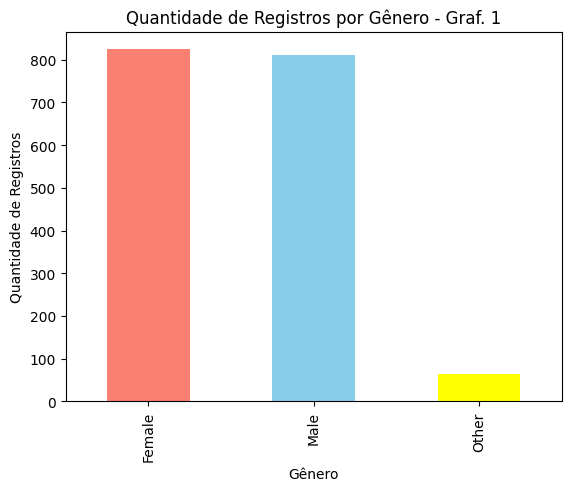

In [77]:
# Importando o pandas e as bibliotecas de gráficos que serão utilizadas

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import gaussian_kde

# importando o DATASET do meu ambiente no GitHub

url = 'https://raw.githubusercontent.com/jefersonferreirafagundes-eng/datasetmvp/refs/heads/main/student_productivity_distraction_dataset_20000.csv'
df = pd.read_csv(url)


## Carregar dataset na variável (apenas os 500 primeiros registros para ver se os graficos de dispersão
# ficam com leitura mais fácil

df = pd.read_csv((url), nrows=1700)

# Mostrar estatisticas descritivas do dataset
df.describe()

# Agrupar e contar os registros por gênero

gender_counts = df['gender'].value_counts()

# Plotar Histograma agrupado por gênero
gender_counts.plot(kind='bar', color=['salmon', 'skyblue', 'yellow'])
plt.title('Quantidade de Registros por Gênero - Graf. 1')
plt.xlabel('Gênero')
plt.ylabel('Quantidade de Registros')
plt.show()

# Criar variável agregada de entretenimento digital
df["Horas Entretenimento"] = df["social_media_hours"] + df["youtube_hours"] + df["gaming_hours"]

# Separar por gênero
male = df[df["gender"] == "Male"]
female = df[df["gender"] == "Female"]

# Função para linha de regressão
#def regression_line(x, y):
 #   m, b = np.polyfit(x, y, 1)
  #  return m, b



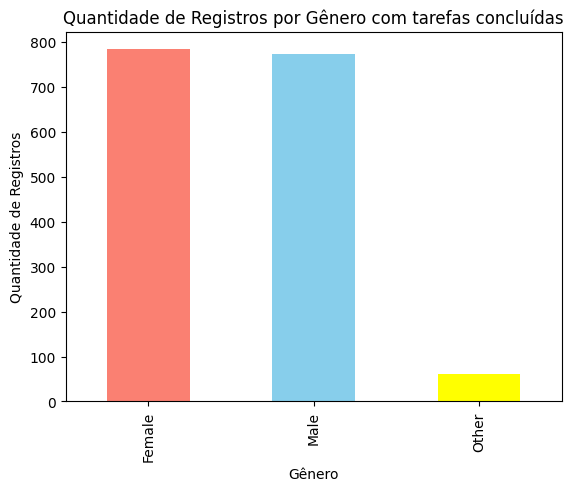

In [78]:
 # Plotar Histograma agrupado por gênero com tarefas concluídas para verificar se
 # o número de registros que não serão tratados foram excluidos

# ignorando registros com "ZERO tarefas concluidas" e gerando novo gráfico por gênero
df_filtered = df[df['assignments_completed'] > 0]

gender_counts = df_filtered['gender'].value_counts()
gender_counts.plot(kind='bar', color=['salmon', 'skyblue', 'yellow'])
plt.title('Quantidade de Registros por Gênero com tarefas concluídas')
plt.xlabel('Gênero')
plt.ylabel('Quantidade de Registros')
plt.show()


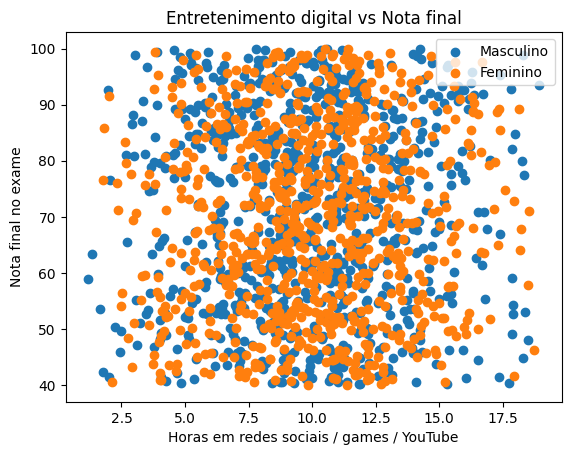

In [79]:
########################################################
# Hipótese 1
# Mais horas de redes sociais/games/youtube -> menor nota
########################################################

plt.figure()

plt.scatter(male["Horas Entretenimento"], male["final_grade"], label="Masculino")
plt.scatter(female["Horas Entretenimento"], female["final_grade"], label="Feminino")

plt.xlabel("Horas em redes sociais / games / YouTube")
plt.ylabel("Nota final no exame")
plt.title("Entretenimento digital vs Nota final")
plt.legend()

plt.show()

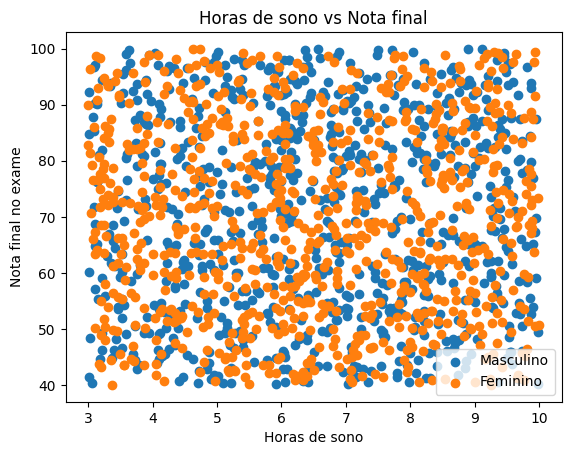

In [80]:
########################################################
# Hipótese 2
# Mais horas de sono -> melhor desempenho
########################################################

plt.figure()

plt.scatter(male["sleep_hours"], male["final_grade"], label="Masculino")
plt.scatter(female["sleep_hours"], female["final_grade"], label="Feminino")

plt.xlabel("Horas de sono")
plt.ylabel("Nota final no exame")
plt.title("Horas de sono vs Nota final")
plt.legend()

plt.show()

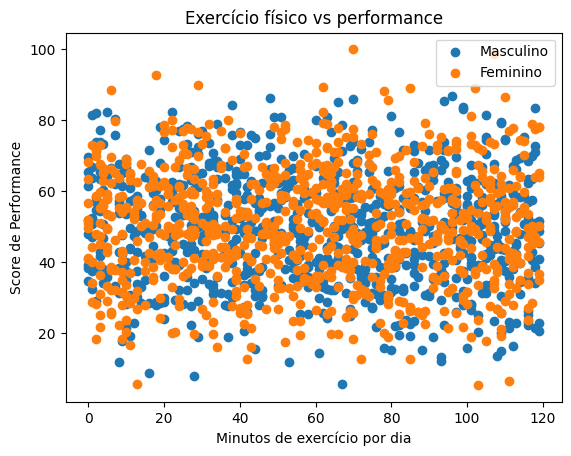

In [81]:
########################################################
# Hipótese 3
# Mais horas de exercício -> maior produtividade acadêmica
########################################################

plt.figure()

plt.scatter(male["exercise_minutes"], male["productivity_score"], label="Masculino")
plt.scatter(female["exercise_minutes"], female["productivity_score"], label="Feminino")

plt.xlabel("Minutos de exercício por dia")
plt.ylabel("Score de Performance")
plt.title("Exercício físico vs performance")
plt.legend()

plt.show()

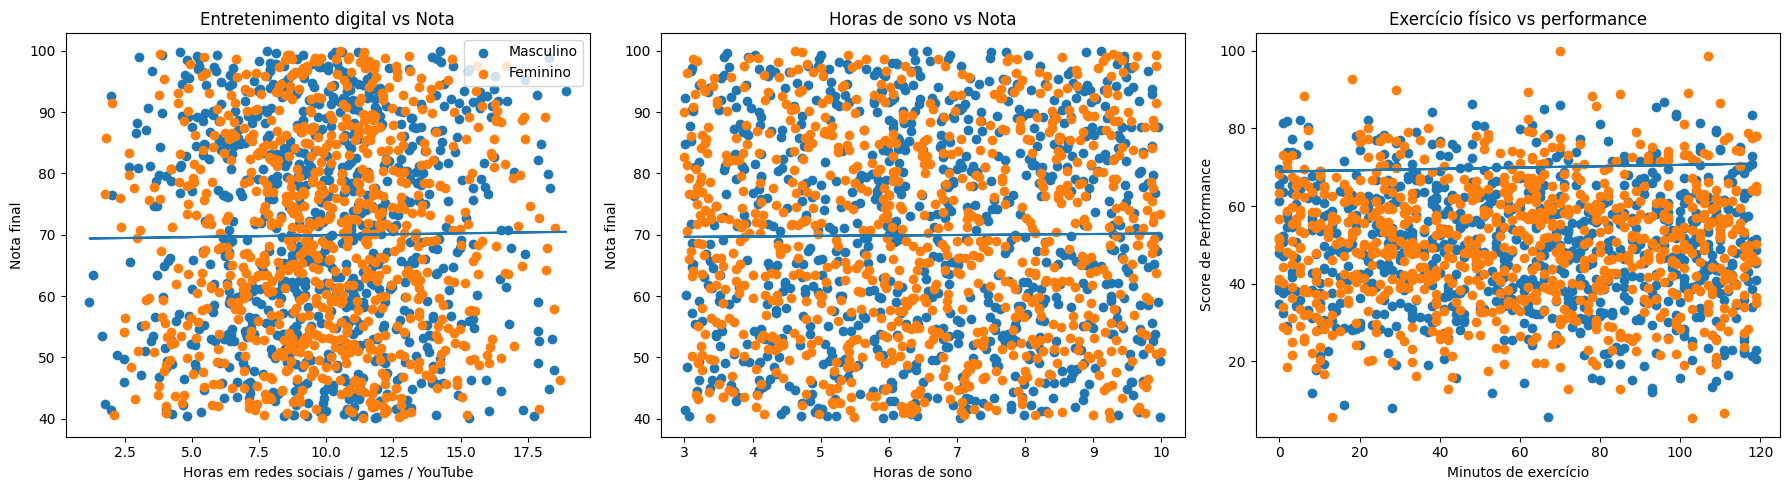

Correlação entretenimento x nota: 0.01222542774829876
Correlação sono x nota: 0.0090609694996823
Correlação performance x nota: 0.034983016070094124


In [82]:
##### Criar dashboard

# Ensure 'entertainment_hours' is created and available for male/female dataframes
df["entertainment_hours"] = (
    df["social_media_hours"] +
    df["youtube_hours"] +
    df["gaming_hours"]
)

# Recreate male and female dataframes to include the new 'entertainment_hours' column
male = df[df["gender"] == "Male"]
female = df[df["gender"] == "Female"]

fig, axes = plt.subplots(1, 3, figsize=(18,5))

####################################################
# Gráfico 1 — Entretenimento digital vs Nota
####################################################

axes[0].scatter(male["entertainment_hours"], male["final_grade"], label="Masculino")
axes[0].scatter(female["entertainment_hours"], female["final_grade"], label="Feminino")

m,b = regression_line(df["entertainment_hours"], df["final_grade"])
axes[0].plot(df["entertainment_hours"], m*df["entertainment_hours"]+b)

axes[0].set_title("Entretenimento digital vs Nota")
axes[0].set_xlabel("Horas em redes sociais / games / YouTube")
axes[0].set_ylabel("Nota final")

axes[0].legend()

####################################################
# Gráfico 2 — Sono vs Nota
####################################################

axes[1].scatter(male["sleep_hours"], male["final_grade"], label="Masculino")
axes[1].scatter(female["sleep_hours"], female["final_grade"], label="Feminino")

m,b = regression_line(df["sleep_hours"], df["final_grade"])
axes[1].plot(df["sleep_hours"], m*df["sleep_hours"]+b)

axes[1].set_title("Horas de sono vs Nota")
axes[1].set_xlabel("Horas de sono")
axes[1].set_ylabel("Nota final")

####################################################
# Gráfico 3 — Exercício vs Nota
####################################################

axes[2].scatter(male["exercise_minutes"], male["productivity_score"], label="Masculino")
axes[2].scatter(female["exercise_minutes"], female["productivity_score"], label="Feminino")

m,b = regression_line(df["exercise_minutes"], df["final_grade"])
axes[2].plot(df["exercise_minutes"], m*df["exercise_minutes"]+b)

axes[2].set_title("Exercício físico vs performance")
axes[2].set_xlabel("Minutos de exercício")
axes[2].set_ylabel("Score de Performance")

plt.tight_layout()
plt.show()

####################################################
# Cálculo das correlações
####################################################

print("Correlação entretenimento x nota:",
      df["entertainment_hours"].corr(df["final_grade"]))

print("Correlação sono x nota:",
      df["sleep_hours"].corr(df["final_grade"]))

print("Correlação performance x nota:",
      df["exercise_minutes"].corr(df["final_grade"]))





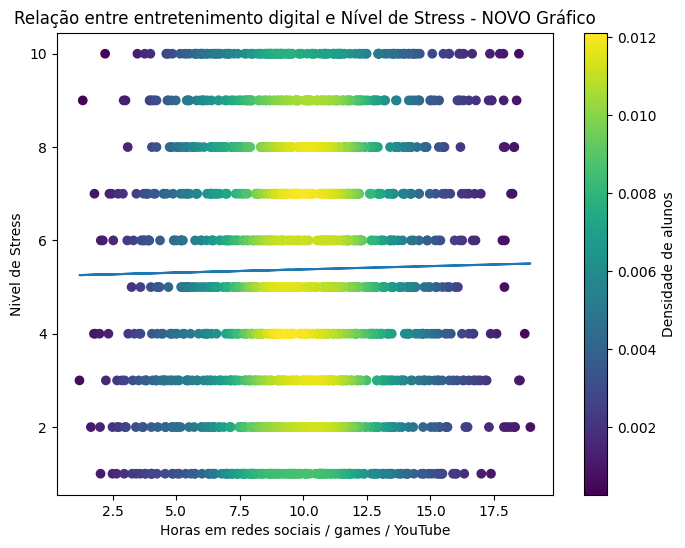

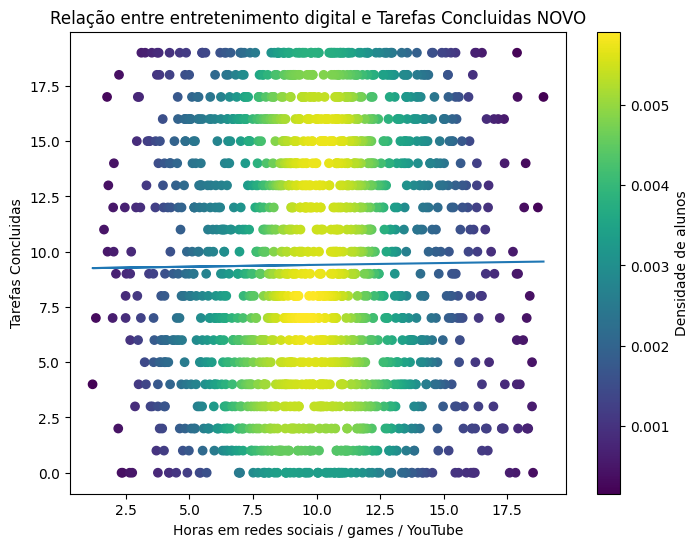

In [83]:
 ### OUTRAS ANALISES ...

   # variável agregada
df["entertainment_hours"] = (
    df["social_media_hours"] +
    df["youtube_hours"] +
    df["gaming_hours"]
)

x = df["entertainment_hours"]
y = df["stress_level"]

# cálculo da densidade de pontos
xy = np.vstack([x, y])
z = gaussian_kde(xy)(xy)

# ordenar pela densidade (melhora visualização)
idx = z.argsort()
x, y, z = x.iloc[idx], y.iloc[idx], z[idx]

plt.figure(figsize=(8,6))

scatter = plt.scatter(x, y, c=z)

# Função para linha de regressão
def regression_line(x, y):
    m, b = np.polyfit(x, y, 1)
    return m, b

# linha de regressão
m, b = np.polyfit(x, y, 1)
plt.plot(x, m*x + b)

plt.xlabel("Horas em redes sociais / games / YouTube")
plt.ylabel("Nivel de Stress")
plt.title("Relação entre entretenimento digital e Nível de Stress - NOVO Gráfico")

plt.colorbar(scatter, label="Densidade de alunos")

plt.show()


### OUTRO GRAFICO COM XXXXX

x = df["entertainment_hours"]
y = df["assignments_completed"]

# cálculo da densidade de pontos
xy = np.vstack([x, y])
z = gaussian_kde(xy)(xy)

# ordenar pela densidade (melhora visualização)
idx = z.argsort()
x, y, z = x.iloc[idx], y.iloc[idx], z[idx]

plt.figure(figsize=(8,6))

scatter = plt.scatter(x, y, c=z)

# linha de regressão
m, b = np.polyfit(x, y, 1)
plt.plot(x, m*x + b)

plt.xlabel("Horas em redes sociais / games / YouTube")
plt.ylabel("Tarefas Concluidas")
plt.title("Relação entre entretenimento digital e Tarefas Concluidas NOVO")

plt.colorbar(scatter, label="Densidade de alunos")

plt.show()
